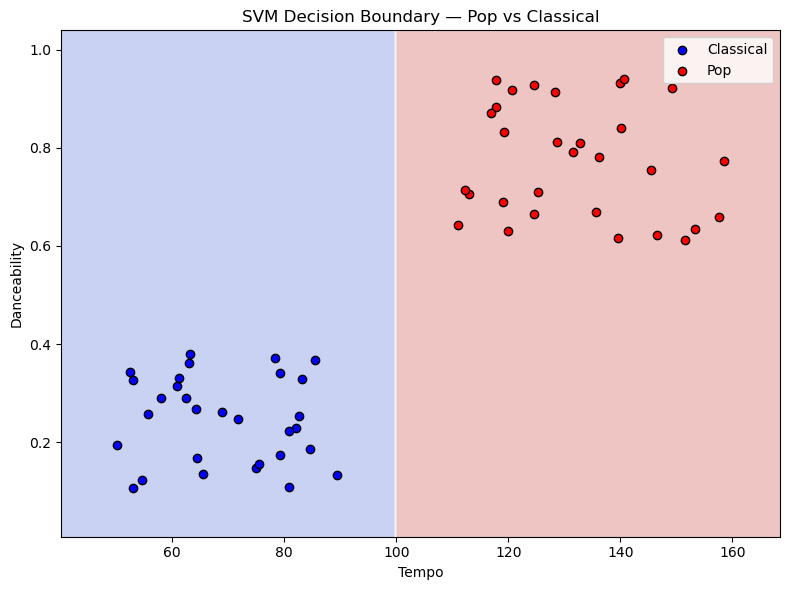

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('music_genre.csv')
df.head(2)

X = df[['tempo', 'danceability']].values   # <-- .values added
le = LabelEncoder()
y = le.fit_transform(df['genre'])

model = SVC(kernel='rbf', C=1.0)
model.fit(X, y)

x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label=le.classes_[0], edgecolor='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label=le.classes_[1], edgecolor='k')
plt.xlabel('Tempo')
plt.ylabel('Danceability')
plt.title('SVM Decision Boundary — Pop vs Classical')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('flipkart_reviews_svm.csv')
df.head(2)

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['review'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.2


In [13]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('ipl_player_performance.csv')

X = df[['runs', 'strike_rate', 'wickets', 'economy']]
y = df['performance_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

#polunominal kernel 

model_poly = SVC(kernel = 'poly' , degree= 3)
model_poly.fit(X_train_s , y_train)
acc_poly = accuracy_score(y_test , model_poly.predict(X_test_s))

#RBF kernel 
model_rbf = SVC(kernel='rbf')
model_rbf.fit(X_train_s, y_train)
acc_rbf = accuracy_score(y_test, model_rbf.predict(X_test_s))

print(f"Polynomial Kernel Accuracy: {acc_poly:.4f}")
print(f"RBF Kernel Accuracy       : {acc_rbf:.4f}")


Polynomial Kernel Accuracy: 0.9375
RBF Kernel Accuracy       : 1.0000
